In [358]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [359]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [360]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [361]:
df.shape

(7043, 21)

In [362]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [363]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [364]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [365]:
df = df.drop("customerID", axis=1)

In [366]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

In [367]:
df.shape
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

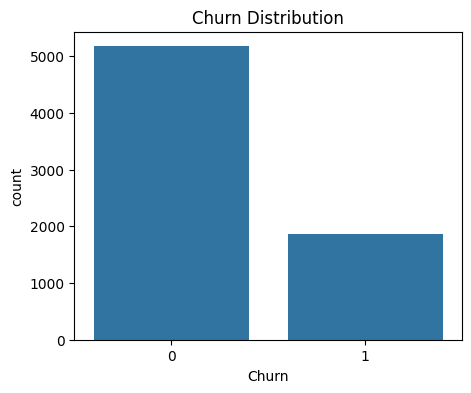

In [368]:
plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

In [369]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [370]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [371]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [372]:
df=df.dropna()

In [373]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

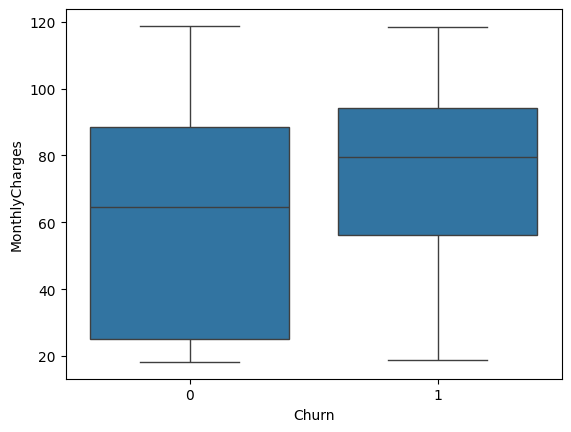

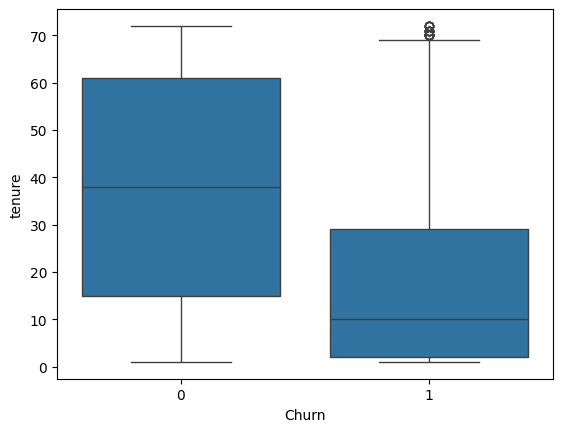

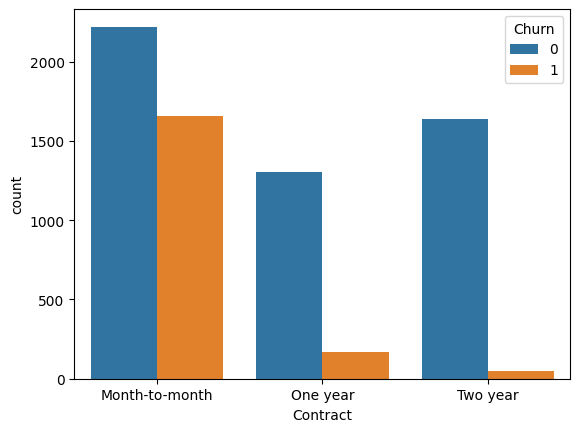

In [374]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()

In [375]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [376]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [377]:
print(X_train.shape)
print(X_test.shape)

(5625, 30)
(1407, 30)


In [378]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

C:\Users\Abhijit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [379]:
y_pred = model.predict(X_test)

In [380]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [381]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob)

0.8320529479062593

In [382]:
coefficients = pd.Series(model.coef_[0], index=X.columns)

coefficients.sort_values(ascending=False).head(10)

InternetService_Fiber optic       0.665545
PaperlessBilling_Yes              0.280150
PaymentMethod_Electronic check    0.263647
MultipleLines_No phone service    0.263018
SeniorCitizen                     0.261563
MultipleLines_Yes                 0.200181
StreamingMovies_Yes               0.198362
StreamingTV_Yes                   0.180276
Partner_Yes                       0.052828
MonthlyCharges                    0.004293
dtype: float64

In [383]:
coefficients.sort_values().head(10)

Contract_Two year                       -1.282629
Contract_One year                       -0.750956
OnlineSecurity_Yes                      -0.471946
TechSupport_Yes                         -0.449042
PhoneService_Yes                        -0.443509
Dependents_Yes                          -0.216192
OnlineBackup_Yes                        -0.148755
PaymentMethod_Credit card (automatic)   -0.134090
OnlineBackup_No internet service        -0.088578
StreamingMovies_No internet service     -0.088578
dtype: float64

In [384]:
for t in [0.3, 0.4, 0.5, 0.6]:
    y_pred = (y_prob > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1033
           1       0.52      0.76      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.77      1407


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1033
           1       0.58      0.65      0.61       374

    accuracy                           0.78      1407
   macro avg       0.72      0.74      0.73      1407
weighted avg       0.79      0.78      0.78      1407


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78   

In [385]:
from sklearn.naive_bayes import BernoulliNB

nb_model = BernoulliNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:,1]

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_nb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_nb))

              precision    recall  f1-score   support

           0       0.90      0.67      0.77      1033
           1       0.47      0.80      0.59       374

    accuracy                           0.71      1407
   macro avg       0.69      0.74      0.68      1407
weighted avg       0.79      0.71      0.72      1407

ROC-AUC: 0.7955982005580547


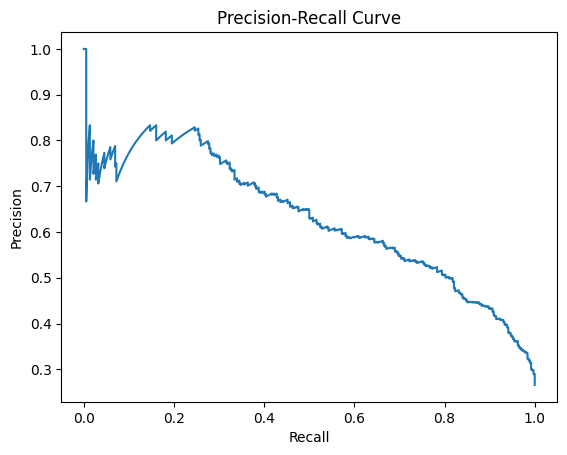

In [386]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [387]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [388]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', probability=True)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:,1]

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_svm))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.54      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407

ROC-AUC: 0.8184924238110276


In [389]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407

ROC-AUC: 0.8160205206785698


In [390]:
for t in [0.3, 0.4, 0.5]:
    y_pred_rf_t = (y_prob_rf > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_rf_t))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.88      0.76      0.82      1033
           1       0.52      0.73      0.61       374

    accuracy                           0.75      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.75      0.76      1407


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1033
           1       0.56      0.58      0.57       374

    accuracy                           0.77      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.77      0.77      0.77      1407


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77   

In [391]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:,1]

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8337418660150852


In [392]:
for t in [0.3, 0.4, 0.5]:
    y_pred_gb_t = (y_prob_gb > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_gb_t))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1033
           1       0.52      0.77      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1033
           1       0.57      0.65      0.60       374

    accuracy                           0.78      1407
   macro avg       0.72      0.73      0.72      1407
weighted avg       0.79      0.78      0.78      1407


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78   

In [393]:
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

In [394]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'gender_Male', 'Partner_Yes',
                                                   'Dependents_Yes',
                                                   'PhoneService_Yes',
                                                   'MultipleLines_No phone '
                                                   'service',
                                                   'MultipleLines_Yes',
                                                   'InternetService_Fiber '
                                                   'optic',
                                                   'InternetService_No',
                                                   'OnlineSecurity_No internet '
                                                   'service...
                                                   'service',
                                                   'StreamingTV_Yes',
                                                   'StreamingMovies_No '
                                                   'internet service',
                                                   'StreamingMovies_Yes',
                                                   'Contract_One year',
                                                   'Contract_Two year',
                                                   'PaperlessBilling_Yes',
                                                   'PaymentMethod_Credit card '
                                                   '(automatic)',
                                                   'PaymentMethod_Electronic '
                                                   'check',
                                                   'PaymentMethod_Mailed '
                                                   'check']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  [])])),
                ('model', LogisticRegression(max_iter=1000))])

In [395]:
X_transformed = pipeline.named_steps['preprocessor'].transform(X_test)

In [396]:
pip install shap


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [397]:
import shap

explainer = shap.Explainer(pipeline.named_steps['model'], X_transformed)

In [398]:
shap_values = explainer(X_transformed)

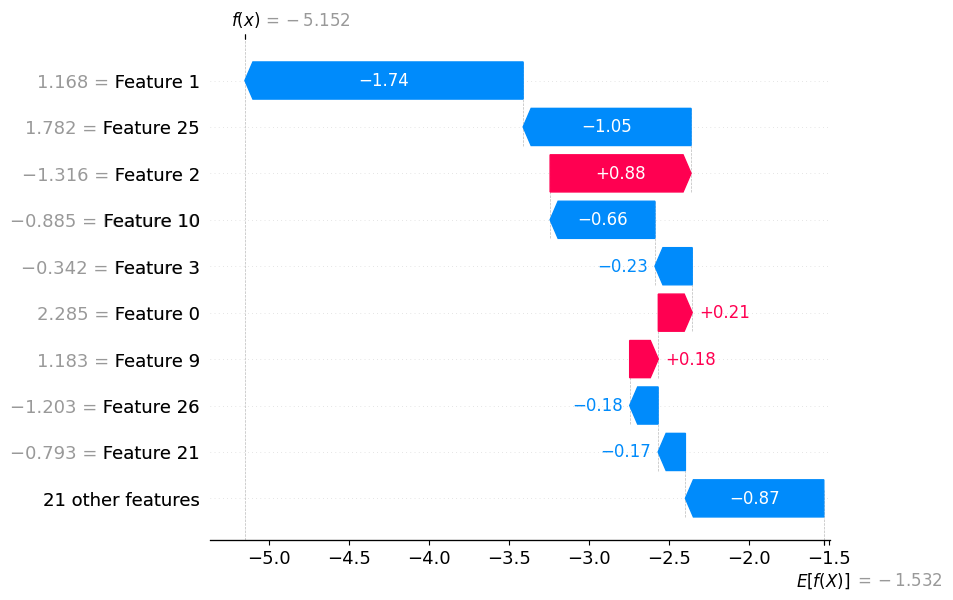

In [399]:
shap.plots.waterfall(shap_values[0])

In [400]:
y_prob = pipeline.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.3).astype(int)

In [401]:
import joblib

joblib.dump(pipeline, "churn_model.pkl")

['churn_model.pkl']

In [402]:
import pandas as pd

feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

coefficients = pipeline.named_steps['model'].coef_[0]

feature_importance = pd.Series(coefficients, index=feature_names)

print(feature_importance.sort_values(ascending=False).head(10))

print(feature_importance.sort_values().head(10))

num__TotalCharges                      0.694885
num__InternetService_Fiber optic       0.650749
num__StreamingMovies_Yes               0.222440
num__StreamingTV_Yes                   0.212963
num__MultipleLines_Yes                 0.160546
num__PaperlessBilling_Yes              0.134580
num__PaymentMethod_Electronic check    0.123558
num__SeniorCitizen                     0.094976
num__DeviceProtection_Yes              0.040129
num__MultipleLines_No phone service    0.029736
dtype: float64
num__tenure                                -1.445747
num__MonthlyCharges                        -0.632801
num__Contract_Two year                     -0.567396
num__Contract_One year                     -0.314562
num__OnlineSecurity_Yes                    -0.155520
num__TechSupport_Yes                       -0.143482
num__Dependents_Yes                        -0.099848
num__OnlineBackup_No internet service      -0.074068
num__StreamingMovies_No internet service   -0.074068
num__StreamingTV_No internet

In [403]:
print(X.columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


In [404]:
X_test.iloc[0].to_dict()

{'SeniorCitizen': 1,
 'tenure': 61,
 'MonthlyCharges': 25.0,
 'TotalCharges': 1501.75,
 'gender_Male': True,
 'Partner_Yes': True,
 'Dependents_Yes': False,
 'PhoneService_Yes': True,
 'MultipleLines_No phone service': False,
 'MultipleLines_Yes': True,
 'InternetService_Fiber optic': False,
 'InternetService_No': True,
 'OnlineSecurity_No internet service': True,
 'OnlineSecurity_Yes': False,
 'OnlineBackup_No internet service': True,
 'OnlineBackup_Yes': False,
 'DeviceProtection_No internet service': True,
 'DeviceProtection_Yes': False,
 'TechSupport_No internet service': True,
 'TechSupport_Yes': False,
 'StreamingTV_No internet service': True,
 'StreamingTV_Yes': False,
 'StreamingMovies_No internet service': True,
 'StreamingMovies_Yes': False,
 'Contract_One year': False,
 'Contract_Two year': True,
 'PaperlessBilling_Yes': False,
 'PaymentMethod_Credit card (automatic)': False,
 'PaymentMethod_Electronic check': False,
 'PaymentMethod_Mailed check': False}

In [405]:
import joblib

joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']

In [406]:
columns = joblib.load("columns.pkl")